# Leg-ablation value study

Measures how well the critic's **value estimate** identifies which legs a body needs. For each
**base morph**, group 0 is the intact body and group *i* removes leg *i*; we compare
**value-predicted importance** `V(intact) - V(ablate_i)` against **realized importance**
`Return(intact) - Return(ablate_i)`, paired within the base morph. Data from
`experiments/leg_ablation_value.py` (one `base_*.npz` per base morph). See `experiments/CONTEXT.md`.

Two value scalars per group: **V@t0** (the critic's initial-state prediction — its purest read of the
morphology) and **mean V** (averaged over the episode). Base leg count is encoded by a light→dark
**purple** gradient throughout.

### Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr, pearsonr

# One stem per checkpoint = the run-dir name the script keyed the output dir by. EDIT THIS.
STEM = "LegAblation"
DATA_DIR = Path("../data/leg_ablation") / STEM

LEG_CODE = {1: "F", 2: "FR", 3: "R", 4: "BR", 5: "B", 6: "BL", 7: "L", 8: "FL"}

def load_base(path):
    d = np.load(path, allow_pickle=True)
    G = len(d["removed_leg"]); epg = int(d["envs_per_group"])
    K, L = d["ep_reward"].shape[1], d["value_steps"].shape[2]
    return {
        "path": path.name,
        "leg_count": int(d["leg_count"]),
        "base_legs": d["base_legs"],
        "removed_leg": d["removed_leg"],                 # [G], 0 = intact reference
        "epg": epg, "K": K, "L": L,
        # [G, epg, K, L] / [G, epg, K]. Upcast value: float16 overflows when averaged over steps.
        "value":  d["value_steps"].astype(np.float32).reshape(G, epg, K, L),
        "reward": d["ep_reward"].reshape(G, epg, K),
        "ep_len": d["ep_len"].reshape(G, epg, K),
        "terminated": d["ep_terminated"].reshape(G, epg, K),
    }

bases = [load_base(p) for p in sorted(DATA_DIR.glob("base_*.npz"))]
print(f"{len(bases)} base morphs from {DATA_DIR}")
assert bases, "no base_*.npz found — set STEM / run experiments/leg_ablation_value.py"

60 base morphs from ../data/leg_ablation/LegAblation


### Per-group aggregates → per-ablation importance pairs

One row per (base morph, removed leg): the intact group is the reference. `pred_imp_t0` /
`pred_imp_mean` use V@t0 / mean-V; `real_imp` uses mean episode return.

In [2]:
def group_stats(b):
    # mean over (envs, episodes); value over steps too. nan = post-episode pad.
    v0   = np.nanmean(b["value"][:, :, :, 0], axis=(1, 2))      # [G] V@t0
    vbar = np.nanmean(b["value"],            axis=(1, 2, 3))    # [G] mean V over episode (per step)
    ret  = b["reward"].mean(axis=(1, 2))                        # [G] mean episode return
    # Realized per-step counterpart to vbar: total reward / total steps (step-weighted).
    # ep_len is int16 -> upcast before summing or the step total overflows.
    retbar = b["reward"].sum(axis=(1, 2)) / b["ep_len"].astype(np.int64).sum(axis=(1, 2))  # [G] reward/step
    return v0, vbar, ret, retbar

rows = []
for bi, b in enumerate(bases):
    v0, vbar, ret, retbar = group_stats(b)
    i0 = int(np.where(b["removed_leg"] == 0)[0][0])            # intact group index
    for g, leg in enumerate(b["removed_leg"]):
        if leg == 0:
            continue
        rows.append({
            "base": bi, "leg_count": b["leg_count"], "removed_leg": int(leg),
            "removed_code": LEG_CODE[int(leg)],
            "V0_intact": v0[i0], "V0_ablate": v0[g],
            "Vbar_intact": vbar[i0], "Vbar_ablate": vbar[g],
            "R_intact": ret[i0], "R_ablate": ret[g],
            "Rbar_intact": retbar[i0], "Rbar_ablate": retbar[g],
            "pred_imp_t0":   v0[i0]   - v0[g],
            "pred_imp_mean": vbar[i0] - vbar[g],
            "real_imp":      retbar[i0]  - retbar[g],
        })
df = pd.DataFrame(rows)
print(df.shape)
df.head()

(330, 15)


,base,leg_count,removed_leg,removed_code,V0_intact,V0_ablate,Vbar_intact,Vbar_ablate,R_intact,R_ablate,Rbar_intact,Rbar_ablate,pred_imp_t0,pred_imp_mean,real_imp
0,0,3,1,F,123.293655,23.748510,164.340546,13.997625,2558.932617,34.966938,3.562930,1.812192,99.545143,150.342926,1.750739
1,0,3,4,BR,123.293655,56.352543,164.340546,26.291990,2558.932617,90.466888,3.562930,1.704745,66.941116,138.048553,1.858185
2,0,3,6,BL,123.293655,72.193527,164.340546,49.139317,2558.932617,143.911041,3.562930,1.917847,51.100128,115.201233,1.645083
3,1,3,1,F,123.235718,22.284258,141.682861,12.549566,1573.398071,33.904819,3.242838,1.767049,100.951462,129.133301,1.475789
4,1,3,4,BR,123.235718,67.751617,141.682861,37.925964,1573.398071,99.010025,3.242838,2.080369,55.484100,103.756897,1.162469


### Headline: does predicted leg importance track realized?

Each point is one ablated leg, coloured by base leg count. Lines are linear fits — one **overall**
(black) and one **per leg count** (purple shades). A positive slope means the critic's value drop on
removing a leg tracks the body's real performance drop.

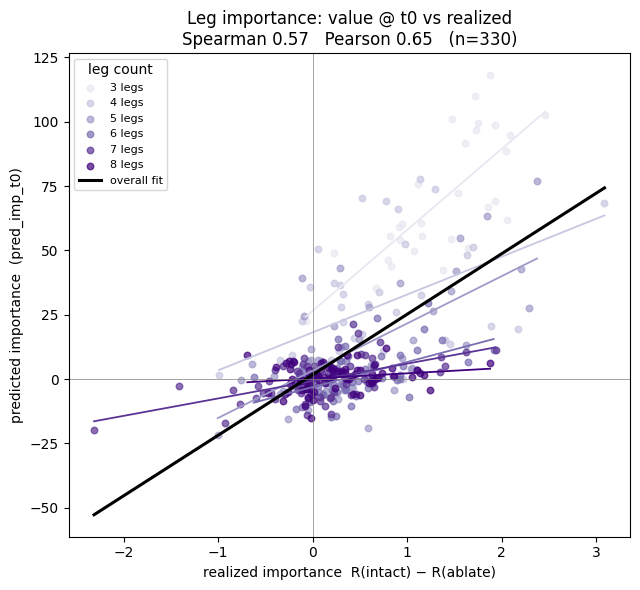

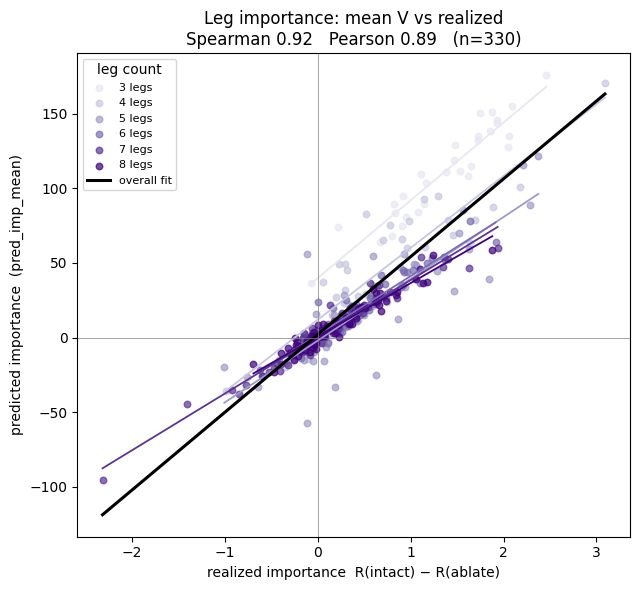

In [3]:
def imp_scatter(df, pred_col, title):
    legs = sorted(df["leg_count"].unique())
    cmap = mpl.cm.Purples
    norm = mpl.colors.Normalize(min(legs) - 1, max(legs))
    fig, ax = plt.subplots(figsize=(6.5, 6))
    for lc in legs:
        s = df[df["leg_count"] == lc]
        col = cmap(norm(lc))
        ax.scatter(s["real_imp"], s[pred_col], s=22, alpha=0.7, color=col, label=f"{lc} legs")
        if len(s) >= 2:                                       # per-leg-count linear fit
            m, c = np.polyfit(s["real_imp"], s[pred_col], 1)
            xs = np.array([s["real_imp"].min(), s["real_imp"].max()])
            ax.plot(xs, m * xs + c, color=col, lw=1.3)
    m, c = np.polyfit(df["real_imp"], df[pred_col], 1)        # overall fit
    xs = np.array([df["real_imp"].min(), df["real_imp"].max()])
    ax.plot(xs, m * xs + c, "k-", lw=2.2, label="overall fit")
    sp = spearmanr(df["real_imp"], df[pred_col]).correlation
    pe = pearsonr(df["real_imp"], df[pred_col])[0]
    ax.set_xlabel("realized importance  R(intact) − R(ablate)")
    ax.set_ylabel(f"predicted importance  ({pred_col})")
    ax.set_title(f"{title}\nSpearman {sp:.2f}   Pearson {pe:.2f}   (n={len(df)})")
    ax.legend(fontsize=8, title="leg count")
    ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
    fig.tight_layout()
    return fig

imp_scatter(df, "pred_imp_t0",   "Leg importance: value @ t0 vs realized");
imp_scatter(df, "pred_imp_mean", "Leg importance: mean V vs realized");

### Per-leg-count correlation

How well predicted tracks realized, broken down by base leg count (more legs → each leg individually
less critical, so the relationship may differ).

In [4]:
g = df.groupby("leg_count")
summary = pd.DataFrame({
    "n": g.size(),
    "spearman_t0":   g.apply(lambda s: spearmanr(s["real_imp"], s["pred_imp_t0"]).correlation),
    "spearman_mean": g.apply(lambda s: spearmanr(s["real_imp"], s["pred_imp_mean"]).correlation),
    "mean_real_imp": g["real_imp"].mean(),
    "mean_pred_t0":  g["pred_imp_t0"].mean(),
})
summary

,n,spearman_t0,spearman_mean,mean_real_imp,mean_pred_t0
leg_count,,,,,
3,30,0.757063,0.939488,1.370477,69.561844
4,40,0.484240,0.889306,0.641390,27.548969
5,50,0.571573,0.817719,0.460472,11.696615
6,60,0.523312,0.925368,0.421986,0.990369
7,70,0.517488,0.963678,0.118010,0.021205
8,80,0.194046,0.964955,0.233357,0.644659


### Value vs. realized return over time (one body)

For a single base morph (leg count set by `SHOW_LEGS`), each line is one removed leg — **intact** in
black — averaged over envs for one episode.

- **Left — predicted value.** The critic's value at each step: its estimate of the **discounted
  return-to-go**, `V(s_t) = E[ Σ_k γ^k · r_{t+k} ]` with γ = 0.98, in the environment's reward units.
  The ⭐ marks **V@t0**, the initial-state prediction (before the body has moved).
- **Middle — realized return.** The *actual* discounted return-to-go `Σ_k γ^k · r_{t+k}` from the
  rollout — the same quantity, same units, that the value curve is trying to predict.
- **Right — value − return.** Predicted minus realized at each step: the critic's **signed error**
  (above the dashed zero line = overestimate, below = underestimate).

Does value collapse mid-episode as an ablated gait fails, even when V@t0 (the ⭐) does not see it
coming?

/tmp/ipykernel_3882075/1813967256.py:28: RuntimeWarning: Mean of empty slice
  v_tr = np.nanmean(b["value"][g, :, episode, :], axis=0)             # predicted value
/tmp/ipykernel_3882075/1813967256.py:31: RuntimeWarning: Mean of empty slice
  r_tr = np.nanmean(return_to_go(rew_steps[g, :, episode, :]), axis=0)  # realized return-to-go


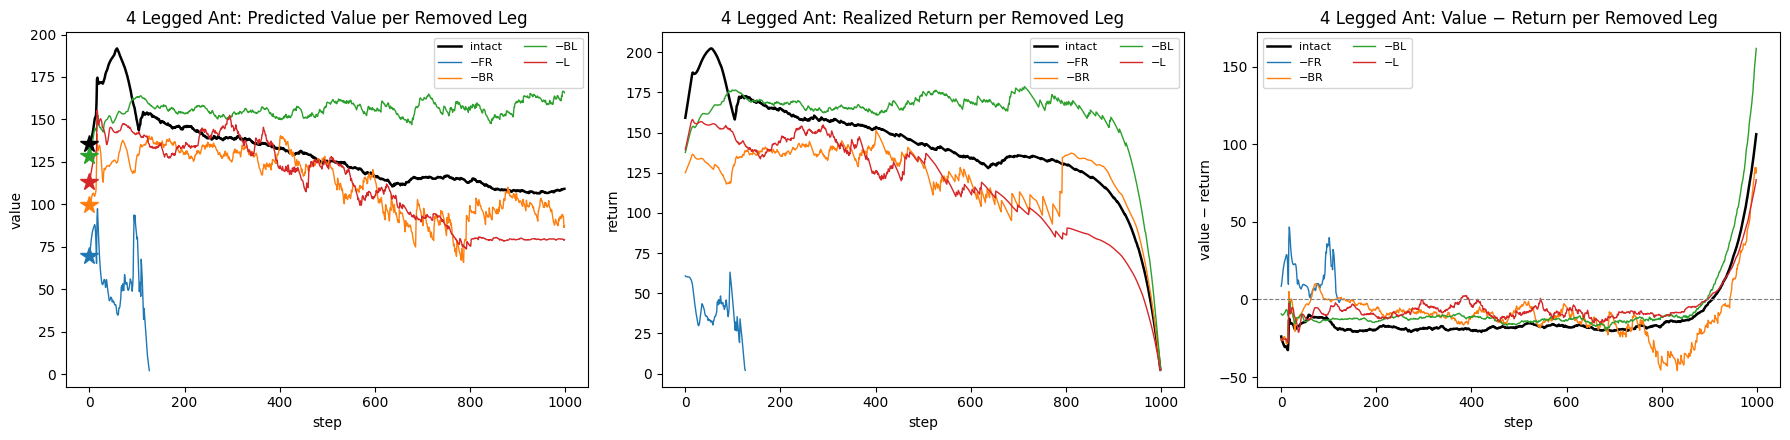

In [6]:
SHOW_LEGS = 4         # which leg-count ant to display (first base of that count)
episode   = 0         # which of the K episodes to trace
GAMMA     = 0.98      # discount (configs/ppo_ant_full.yaml)

b = next(x for x in bases if x["leg_count"] == SHOW_LEGS)
N = b["leg_count"]
G = len(b["removed_leg"])
# reward_steps isn't kept in memory for all bases (doubles RAM); lazy-load just this one.
rew_steps = np.load(DATA_DIR / b["path"], allow_pickle=True)["reward_steps"]
rew_steps = rew_steps.astype(np.float32).reshape(G, b["epg"], b["K"], b["L"])

def return_to_go(rew):
    # discounted return-to-go per env: sum_{k>=0} gamma^k r_{t+k}; nan after the episode ends.
    valid = np.isfinite(rew)
    r = np.where(valid, rew, 0.0)
    out = np.zeros_like(r); acc = np.zeros(r.shape[0], dtype=np.float32)
    for t in range(r.shape[1] - 1, -1, -1):
        acc = r[:, t] + GAMMA * acc
        out[:, t] = acc
    out[~valid] = np.nan
    return out

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for g, leg in enumerate(b["removed_leg"]):
    intact = leg == 0
    lbl = "intact" if intact else f"−{LEG_CODE[int(leg)]}"
    lw = 1.8 if intact else 1.0
    v_tr = np.nanmean(b["value"][g, :, episode, :], axis=0)             # predicted value
    (line,) = axes[0].plot(v_tr, lw=lw, color="k" if intact else None, label=lbl)
    axes[0].plot(0, v_tr[0], marker="*", ms=13, color=line.get_color(), zorder=5)  # V@t0
    r_tr = np.nanmean(return_to_go(rew_steps[g, :, episode, :]), axis=0)  # realized return-to-go
    axes[1].plot(r_tr, lw=lw, color=line.get_color(), label=lbl)
    axes[2].plot(v_tr - r_tr, lw=lw, color=line.get_color(), label=lbl)   # critic error (predicted − realized)

axes[0].set_title(f"{N} Legged Ant: Predicted Value per Removed Leg")
axes[1].set_title(f"{N} Legged Ant: Realized Return per Removed Leg")
axes[2].set_title(f"{N} Legged Ant: Value − Return per Removed Leg")
axes[2].axhline(0, color="grey", lw=0.8, ls="--")
for ax, yl in zip(axes, ("value", "return", "value − return")):
    ax.set_xlabel("step"); ax.set_ylabel(yl); ax.legend(fontsize=8, ncol=2)
fig.tight_layout()